# 04 Sales Prediction Model

This notebook builds a simple sales prediction model using `LinearRegression`. The code is kept direct so it is easy to explain.


## Import Libraries and Load Data


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [2]:
cleaned_path = '../data/processed/cleaned_luminatech_transactions.csv'
sample_path = '../data/sample/sample_luminatech_data.csv'

if os.path.exists(cleaned_path):
    Dataset_cleaned = pd.read_csv(cleaned_path, dtype={'customer_code': str}, low_memory=False)
else:
    Dataset_cleaned = pd.read_csv(sample_path, dtype={'customer_code': str})

Dataset_cleaned.head()


,accounting_date,fiscal_year,fiscal_month,calendar_year,calendar_month,calendar_day,company_code,customer_code,customer_district_code,item_code,...,value_price_adjustment,currency,invoice_number,line_number,invoice_date,customer_order_number,order_date,dss_update_time,profit,time_gap
0,2012-05-09,2012,11,2012,5,9,101,411800601,410,GENIE8WWWBC,...,0,AUD,2217887,1,2012-05-09,2865354,2012-05-09,49:58.7,40.2024,0
1,2012-02-16,2012,8,2012,2,16,101,361000403,300,GENIE8WWWBC,...,0,AUD,2185745,1,2012-02-16,2833515,2012-02-16,49:58.7,12.8232,0
2,2012-05-09,2012,11,2012,5,9,101,361000403,300,GENIE8WWWBC,...,0,AUD,2217807,1,2012-05-09,2864857,2012-05-08,49:58.7,14.7432,1
3,2012-05-18,2012,11,2012,5,18,101,565540415,500,GENIE8WWWBC,...,0,AUD,2222758,1,2012-05-18,2869759,2012-05-18,49:58.7,7.3716,0
4,2012-01-09,2012,7,2012,1,9,101,565540415,500,GENIE8WWWBC,...,0,AUD,2170374,1,2012-01-09,2819189,2012-01-09,49:58.7,6.4116,0


## Select Features and Target

`value_sales` is the target. We should not use `value_sales` as an input because it is the value we are trying to predict.


In [3]:
selected_features = [
    'customer_district_code',
    'value_cost',
    'value_quantity',
    'fiscal_year',
    'fiscal_month',
    'order_type_code',
    'item_type',
    'item_class_code',
    'market_segment',
    'company_code'
]

data_model = Dataset_cleaned[selected_features + ['value_sales']].copy()
data_model = data_model.replace([np.inf, -np.inf], np.nan).dropna()

data_model.head()


,customer_district_code,value_cost,value_quantity,fiscal_year,fiscal_month,order_type_code,item_type,item_class_code,market_segment,company_code,value_sales
0,410,178.1976,84.0,2012,11,NOR,5,LMP01,Commercial & Industrial,101,218.40
1,300,25.4568,12.0,2012,8,NOR,5,LMP01,Commercial & Industrial,101,38.28
2,300,25.4568,12.0,2012,11,NOR,5,LMP01,Commercial & Industrial,101,40.20
3,500,12.7284,6.0,2012,11,EDI,5,LMP01,Commercial & Industrial,101,20.10
4,500,12.7284,6.0,2012,7,EDI,5,LMP01,Commercial & Industrial,101,19.14


## Convert Categorical Columns

Machine learning models need numeric inputs, so we convert text/code categories into dummy variables.


In [4]:
categorical_columns = ['order_type_code', 'item_type', 'item_class_code', 'market_segment', 'company_code']

data_model = pd.get_dummies(data_model, columns=categorical_columns, drop_first=True)

y = data_model['value_sales']
X = data_model.drop('value_sales', axis=1)

print('X shape:', X.shape)
print('y shape:', y.shape)


X shape: (1966082, 261)
y shape: (1966082,)


## Train-Test Split and Model Training


In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)


## Model Evaluation


In [6]:
rmse = np.sqrt(mean_squared_error(y_test, predictions))
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print('RMSE:', rmse)
print('MAE:', mae)
print('R-squared:', r2)


RMSE: 836.2875006222288
MAE: 144.41196259107224
R-squared: 0.9197945272377211


## Actual vs Predicted Sales Chart


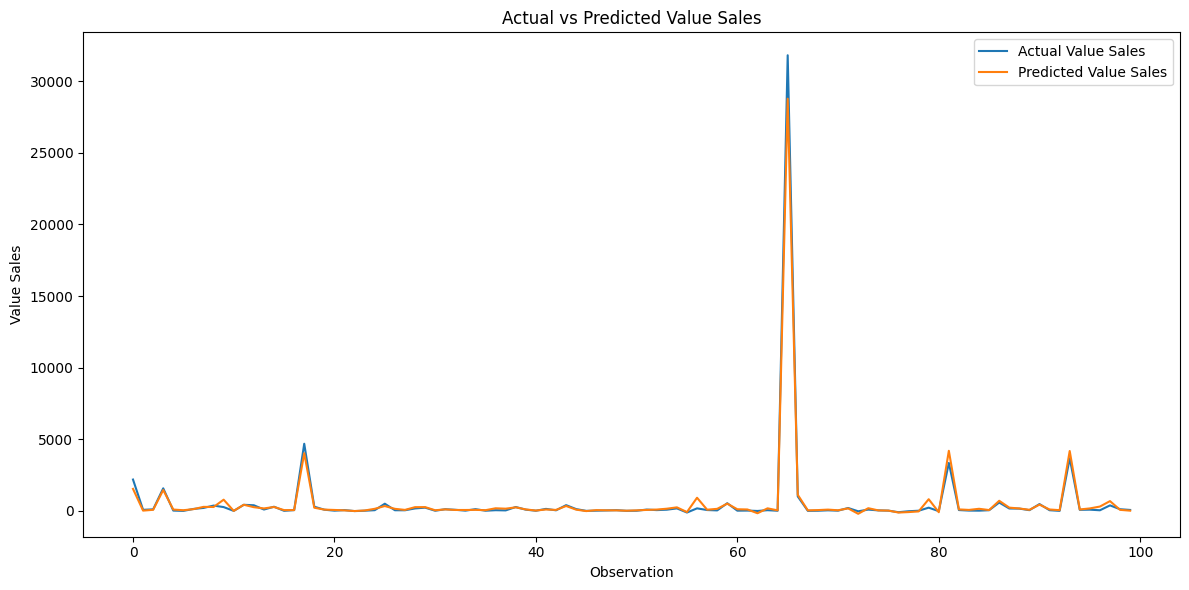

In [7]:
comparison_df = pd.DataFrame({
    'Actual Value Sales': y_test.values,
    'Predicted Value Sales': predictions
})

plt.figure(figsize=(12, 6))
plt.plot(comparison_df['Actual Value Sales'].head(100).values, label='Actual Value Sales')
plt.plot(comparison_df['Predicted Value Sales'].head(100).values, label='Predicted Value Sales')
plt.title('Actual vs Predicted Value Sales')
plt.xlabel('Observation')
plt.ylabel('Value Sales')
plt.legend()
plt.tight_layout()
plt.savefig('../visuals/08_actual_vs_predicted_sales.png', dpi=160)
plt.show()


## Limitation Note

This is a baseline model. A stronger business forecasting model should use a time-based split, check for data leakage, and test whether outliers are affecting the results.
